Загружено строк: 920
Колонки: ['emotion', 'pixels', 'Usage']
Уникальные эмоции: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


/tmp/ipykernel_57/1485064058.py:51: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array, mode="L").convert("RGB")  # grayscale → RGB


  Обработано 100/920
  Обработано 200/920
  Обработано 300/920
  Обработано 400/920
  Обработано 500/920
  Обработано 600/920
  Обработано 700/920
  Обработано 800/920
  Обработано 900/920

✅ Готово: 920 изображений в /kaggle/working/ck_processed/train
✅ Metadata: /kaggle/working/ck_processed/metadata.csv

Пример восстановленного изображения ((512, 512)):


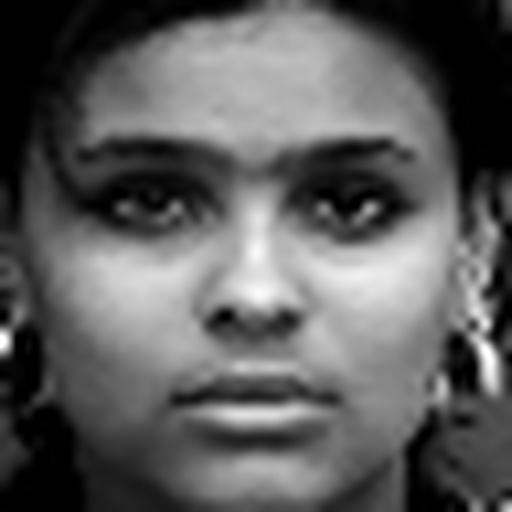

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image

# ========== НАСТРОЙКИ ==========
CSV_PATH = "/kaggle/input/datasets/davilsena/ckdataset/ckextended.csv"
OUTPUT_DIR = "/kaggle/working/ck_processed/train"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Словарь: номер эмоции → промпт
# CK+: 0=neutral, 1=anger, 2=contempt, 3=disgust, 4=fear, 5=happiness, 6=sadness, 7=surprise
EMOTION_MAP = {
    0: "a person with a neutral expression",
    1: "a person looking very angry",
    2: "a person with a contempt expression",
    3: "a person looking disgusted",
    4: "a person with a scared expression",
    5: "a person smiling happily",
    6: "a person looking sad and thoughtful",
    7: "a person with a surprised expression",
}

# ========== ЗАГРУЗКА CSV ==========
df = pd.read_csv(CSV_PATH)
print(f"Загружено строк: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Уникальные эмоции: {sorted(df['emotion'].unique())}")

# ========== ВОССТАНОВЛЕНИЕ ИЗОБРАЖЕНИЙ ==========
metadata_lines = []
image_size = 48  # CK+ обычно 48x48, но проверим по длине пикселей

for idx, row in df.iterrows():
    emotion = int(row["emotion"])
    pixels_str = row["pixels"]
    
    # Парсим строку пикселей в массив
    pixels = np.array([int(p) for p in pixels_str.split()], dtype=np.uint8)
    
    # Определяем размер изображения
    num_pixels = len(pixels)
    side = int(np.sqrt(num_pixels))
    
    if side * side != num_pixels:
        print(f"[WARN] Строка {idx}: {num_pixels} пикселей — не квадрат, пропускаем")
        continue
    
    # Восстанавливаем изображение
    img_array = pixels.reshape(side, side)
    img = Image.fromarray(img_array, mode="L").convert("RGB")  # grayscale → RGB
    img = img.resize((512, 512), Image.LANCZOS)
    
    # Сохраняем
    filename = f"ck_{idx:05d}_emotion_{emotion}.png"
    filepath = os.path.join(OUTPUT_DIR, filename)
    img.save(filepath)
    
    # Промпт
    prompt = EMOTION_MAP.get(emotion, "a person")
    metadata_lines.append(f"{filename},{prompt}")
    
    if (idx + 1) % 100 == 0:
        print(f"  Обработано {idx + 1}/{len(df)}")

# ========== СОХРАНЯЕМ METADATA ==========
metadata_path = "/kaggle/working/ck_processed/metadata.csv"
with open(metadata_path, "w", encoding="utf-8") as f:
    f.write("file_name,text\n")
    f.write("\n".join(metadata_lines))

print(f"\n✅ Готово: {len(metadata_lines)} изображений в {OUTPUT_DIR}")
print(f"✅ Metadata: {metadata_path}")

# Проверка — покажем одно изображение
from IPython.display import display
sample_img = Image.open(os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0]))
print(f"\nПример восстановленного изображения ({sample_img.size}):")
display(sample_img)

In [2]:
#chast' 2

In [ ]:
import torch
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from diffusers import StableDiffusionPipeline
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# ========== НАСТРОЙКИ ==========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

TRAIN_DIR = "/kaggle/working/ck_processed/train"
METADATA_FILE = "/kaggle/working/ck_processed/metadata.csv"
LORA_OUTPUT = "/kaggle/working/lora_emotion"

NUM_EPOCHS = 30
BATCH_SIZE = 1
LEARNING_RATE = 1e-4
RANK = 4

# ========== ДАТАСЕТ ==========
class EmotionDataset(Dataset):
    def __init__(self, metadata_file, train_dir):
        self.train_dir = train_dir
        with open(metadata_file, "r") as f:
            lines = f.read().strip().split("\n")[1:]
        self.data = [line.split(",", 1) for line in lines if line.strip()]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_name, prompt = self.data[idx]
        img = Image.open(os.path.join(self.train_dir, file_name)).convert("RGB")
        img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 127.5 - 1.0
        return {"pixel_values": img, "prompt": prompt}

dataset = EmotionDataset(METADATA_FILE, TRAIN_DIR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Датасет: {len(dataset)} изображений")

# ========== ЗАГРУЗКА МОДЕЛИ ==========
print("Загрузка SD1.5...")
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V4.0_noVAE",
    torch_dtype=DTYPE,
    use_safetensors=True,
)
pipe = pipe.to(DEVICE)

unet = pipe.unet
unet.train()

for param in unet.parameters():
    param.requires_grad = False

# ========== LoRA ==========
lora_config = LoraConfig(
    r=RANK,
    lora_alpha=RANK,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.0,
    bias="none",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

optimizer = AdamW(unet.parameters(), lr=LEARNING_RATE)
noise_scheduler = pipe.scheduler

# Кодируем текст
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer

prompts = [item[1] for item in dataset.data] 
encoded_prompts = []
for prompt in tqdm(prompts, desc="Кодирование текста"):
    tokens = tokenizer(
        prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt"
    ).input_ids.to(DEVICE)
    with torch.no_grad():
        emb = text_encoder(tokens).last_hidden_state
    encoded_prompts.append(emb)

# ========== ОБУЧЕНИЕ С ГРАФИКОМ ==========
print(f"\nОбучение {NUM_EPOCHS} эпох (loss = MSE шума)...")
epoch_losses = []
batch_losses = []

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch_idx, batch in pbar:
        optimizer.zero_grad()

        img = batch["pixel_values"].to(DEVICE, dtype=DTYPE)
        prompt_emb = encoded_prompts[batch_idx]

        # Сначала кодируем изображение в латентное пространство
        with torch.no_grad():
            latents = pipe.vae.encode(img).latent_dist.sample() * pipe.vae.config.scaling_factor
        
        # Добавляем шум в латентном пространстве
        noise = torch.randn_like(latents)
        timestep = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=DEVICE)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timestep)
        
        # UNet предсказывает шум в латентном пространстве
        noise_pred = unet(noisy_latents, timestep, encoder_hidden_states=prompt_emb).sample
        loss = F.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_losses.append(loss.item())
        pbar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: avg_loss = {avg_loss:.6f}")

# ========== СОХРАНЕНИЕ ==========
unet.save_pretrained(LORA_OUTPUT)
print(f"\n✅ LoRA сохранена: {LORA_OUTPUT}")

# ========== ГРАФИК ЛОССА ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Средний loss по эпохам
axes[0].plot(range(1, NUM_EPOCHS+1), epoch_losses, 'b-o', markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss (noise prediction)")
axes[0].set_title("Средний loss по эпохам")
axes[0].grid(True, alpha=0.3)

# График 2: Сглаженный loss по батчам
from scipy.ndimage import uniform_filter1d
smoothed = uniform_filter1d(batch_losses, size=10)
axes[1].plot(batch_losses, alpha=0.2, color='blue', label='Per batch')
axes[1].plot(smoothed, color='red', label='Smoothed (window=10)')
axes[1].set_xlabel("Batch")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Loss по батчам (сглаженный)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_plot.png", dpi=150)
plt.show()

print(f"✅ График сохранён: /kaggle/working/loss_plot.png")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Датасет: 920 изображений
Загрузка SD1.5...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

...


Epoch 22/30:  48%|████▊     | 442/920 [07:59<08:38,  1.08s/it, loss=0.0282]

Epoch 22/30: 100%|██████████| 920/920 [16:38<00:00,  1.09s/it, loss=0.0029]


Epoch 22: avg_loss = 0.066975



Epoch 23/30: 100%|██████████| 920/920 [16:38<00:00,  1.09s/it, loss=0.00393]


Epoch 23: avg_loss = 0.062071



Epoch 26/30:  21%|██▏       | 196/920 [03:33<13:09,  1.09s/it, loss=0.00734]

Epoch 26/30:  69%|██████▉   | 637/920 [11:32<05:05,  1.08s/it, loss=0.252] 

Epoch 30/30:  43%|████▎     | 397/920 [07:11<09:28,  1.09s/it, loss=0.00946]

In [ ]:
3

In [4]:
# Просто печатаем что-то каждые 30 секунд
import time

while True:
    print(".", end="", flush=True)
    time.sleep(30)

......................

KeyboardInterrupt: 

In [8]:
!zip -r lora_emotion.zip /kaggle/working/

updating: kaggle/working/lora_emotion/ (stored 0%)
updating: kaggle/working/lora_emotion/README.md (deflated 65%)
updating: kaggle/working/lora_emotion/adapter_model.safetensors (deflated 8%)
updating: kaggle/working/lora_emotion/adapter_config.json (deflated 57%)
  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/loss_plot.png (deflated 8%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 60%)
  adding: kaggle/working/ck_processed/ (stored 0%)
  adding: kaggle/working/ck_processed/train/ (stored 0%)
  adding: kaggle/working/ck_processed/train/ck_00295_emotion_6.png (deflated 0%)
  adding: kaggle/working/ck_processed/train/ck_00901_emotion_5.png (deflated 0%)
  adding: kaggle/working/ck_processed/train/ck_00326_emotion_6.png (deflated 0%)
  adding: kaggle/working/ck_processed/train/ck_00228_emotion_6.png (deflated 0%)
  adding: kaggle/working/ck_processed/train/ck_00220_emotion_6.png (de

In [ ]:
import torch
import numpy as np
from PIL import Image
from diffusers import StableDiffusionPipeline
from peft import PeftModel
from insightface.app import FaceAnalysis

# ========== НАСТРОЙКИ ==========
DEVICE = "cuda"
DTYPE = torch.float16

LORA_PATH = "/kaggle/working/lora_emotion"
REFERENCES_DIR = "/kaggle/input/datasets/kolyagudkov/ref1-diplom"
RESULTS_DIR = "/kaggle/working/results_lora_emotion"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Флаги — меняй для эксперимента
USE_LORA = True
USE_IP_ADAPTER = True
ADAPTER_TYPE = "face"  # "face" или "plus"

# Промпты разные, чтобы проверить обобщение
TEST_PROMPTS = [
    "a person looking very angry, cartoon style",
    "a person smiling happily, sticker style",
    "a person with a surprised expression, comic style",
    "a person crying with tears, sad style",
]

# ========== ЗАГРУЗКА ==========
print("Загрузка SD1.5...")
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V4.0_noVAE",
    torch_dtype=DTYPE,
    use_safetensors=True,
)
pipe = pipe.to(DEVICE)

# Загружаем LoRA
if USE_LORA:
    print("Загрузка LoRA...")
    pipe.unet = PeftModel.from_pretrained(pipe.unet, LORA_PATH)
    pipe.unet.set_adapter("default")

# Загружаем IP-Adapter
if USE_IP_ADAPTER:
    print("Загрузка IP-Adapter...")
    if ADAPTER_TYPE == "face":
        weight_name = "ip-adapter-plus-face_sd15.safetensors"
    else:
        weight_name = "ip-adapter-plus_sd15.safetensors"

    pipe.load_ip_adapter(
        "h94/IP-Adapter",
        subfolder="models",
        weight_name=weight_name,
        image_encoder_folder="models/image_encoder",
    )
    pipe.set_ip_adapter_scale(0.7)

    # Загружаем референс
    ref_files = sorted([f for f in os.listdir(REFERENCES_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    ref_image = Image.open(os.path.join(REFERENCES_DIR, ref_files[0])).convert("RGB")

# ========== ГЕНЕРАЦИЯ ==========
print("\nГенерация...")
for i, prompt in enumerate(TEST_PROMPTS):
    config_name = f"LoRA_{USE_LORA}_IP_{USE_IP_ADAPTER}_{ADAPTER_TYPE}"
    filename = f"{config_name}_prompt_{i:02d}.png"
    filepath = os.path.join(RESULTS_DIR, filename)

    kwargs = {
        "prompt": prompt,
        "negative_prompt": "low quality, blurry, distorted, ugly, bad anatomy",
        "num_inference_steps": 30,
        "guidance_scale": 7.0,
        "generator": torch.Generator(device=DEVICE).manual_seed(42),
        "height": 512,
        "width": 512,
    }

    if USE_IP_ADAPTER:
        kwargs["ip_adapter_image"] = ref_image

    result = pipe(**kwargs)
    result.images[0].save(filepath)
    print(f"[OK] {filename}")

print(f"\n✅ Готово: {RESULTS_DIR}")